## LSTM Neural Network for Volatility Forecasting

In this notebook, we develop and evaluate a Long Short-Term Memory (LSTM) neural network to forecast the future realized volatility of 2800.HK. 

Imports

In [18]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

import os
from pathlib import Path

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Load Processed Volatility & Return Data

We import the pre-exported datasets created in the data-processing notebook

In [19]:
# Load future-realized volatility target for 2800.HK
train_df = pd.read_excel('../data/hsi_vol_train.xlsx').set_index('date')
train_hsi = train_df['2800.HK'] # select target column explicitly

train_hsi # Quick display for sanity check

date
2002-05-14   -3.178702
2002-05-15   -3.173177
2002-05-16   -3.122987
2002-05-17   -3.165196
2002-05-21   -3.309047
                ...   
2021-12-24   -2.850449
2021-12-28   -2.850886
2021-12-29   -2.807102
2021-12-30   -2.794930
2021-12-31   -2.787847
Name: 2800.HK, Length: 4847, dtype: float64

### Construct Supervised Sequences for LSTM Input

LSTMs require sequence-to-one training samples.  
We transform the realized volatility series into overlapping windows

In [20]:
def make_dataset(series, seq_len=60):
    """
    Convert a 1D time series into LSTM training sequences.
    
    X: shape (samples, seq_len, 1)
       - past volatility values
    Y: shape (samples,)
       - next-step realized volatility
    """
    data = series.values
    X, Y = [], []

    # Sliding window: last `seq_len` points → predict next point
    for t in range(seq_len, len(data)):
        X.append(data[t-seq_len:t])  # input sequence
        Y.append(data[t])            # next-step target
    
    # Convert to array format required by PyTorch
    X = np.array(X)[:, :, None]  # add feature dimension
    Y = np.array(Y)

    return X, Y

# Create supervised dataset from the training realized volatility series
X, Y = make_dataset(train_hsi, seq_len=1) # A sequence length of 1 reduces the LSTM to an autoregressive model.

### Convert Data to PyTorch Tensors and Create Train/Test Dataloaders

We convert the supervised sequences into PyTorch tensors and split them into training and test sets while preserving temporal order.

In [21]:
# Convert numpy arrays to PyTorch tensors for model training
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

# Train/test split WITHOUT shuffling (time-dependent data!)
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
Y_train, Y_test = Y_tensor[:split], Y_tensor[split:]

# Bundle features and targets into Dataset objects
train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test,  Y_test)

# Create loaders for batch training; maintain order by turning off shuffling
train_loader = DataLoader(train_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

### LSTM Model Architecture

We define a deep LSTM network for volatility forecasting.

In [22]:

class DeepVolLSTM(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 128,
        num_layers: int = 3,
        dropout: float = 0.3,
        bidirectional: bool = False,
        use_layernorm: bool = True,
    ):
        """
        Deep LSTM model for volatility forecasting.

        Args:
            input_dim: number of features per timestep (1 for univariate series)
            hidden_dim: number of hidden units in each LSTM layer
            num_layers: number of stacked LSTM layers 
            dropout: dropout rate applied between LSTM layers and inside MLP
            bidirectional: whether to use a forward + backward LSTM
            use_layernorm: apply layer normalization for training stability
        """
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        # LSTM stack
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )

        lstm_out_dim = hidden_dim * self.num_directions

        # Optional normalization on top of LSTM output
        self.use_layernorm = use_layernorm
        if use_layernorm:
            self.ln = nn.LayerNorm(lstm_out_dim)

        # MLP head for volatility mapping
        self.mlp = nn.Sequential(
            nn.Linear(lstm_out_dim, lstm_out_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim // 2, 1),
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through LSTM → take last hidden state → map to volatility.
        
        Input:
            x: (batch_size, seq_len, input_dim)
        Output:
            (batch_size, 1) next-step volatility forecast
        """
        # LSTM forward
        # out: (batch_size, seq_len, hidden_dim * num_directions)
        out, _ = self.lstm(x)

        # Use last time step's hidden state
        last_out = out[:, -1, :]  # (batch_size, hidden_dim * num_directions)

        if self.use_layernorm:
            last_out = self.ln(last_out)

        # MLP head
        vol_raw = self.mlp(last_out)  # (batch_size, 1)

        return vol_raw

### Instantiate the LSTM Model

We configure the LSTM

In [23]:
# Model architecture configuration
input_dim = 1       # univariate volatility input
hidden_dim = 128    # model capacity per recurrent layer
num_layers = 3      # number of stacked LSTMs

# Initialize model for next-step volatility forecasting
model = DeepVolLSTM(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=0.3,
    bidirectional=False,  # causal (forward-only) forecasting
    use_layernorm=True,   # improve training stability
)

model  # show model architecture summary

DeepVolLSTM(
  (lstm): LSTM(1, 128, num_layers=3, batch_first=True, dropout=0.3)
  (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

### Model Training with Early Stopping and Learning Rate Scheduling

We train the LSTM using mean squared error loss and Adam optimization.

In [24]:
# Optimizer and loss function
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=1e-3, 
    weight_decay=1e-5
    )
loss_fn = nn.MSELoss()

# Reduce LR by factor 2 when val loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5,       # allow a few stagnant epochs
)

epochs = 100
early_stop_patience = 20 # avoid long overfitting runs
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    # Training loop
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation loop
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in test_loader:
            pred = model(x_val)
            test_loss += loss_fn(pred, y_val).item()
    test_loss /= len(test_loader)

    # LR scheduling based on validation loss
    scheduler.step(test_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Test: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping logic
    if test_loss < best_val_loss - 1e-6:
        best_val_loss = test_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}!")
        break


/Users/thijsmanuel/ECON4130_Term_Paper/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/thijsmanuel/ECON4130_Term_Paper/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([36])) that is different to the input size (torch.Size([36, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/Users/thijsmanuel/ECON4130_Term_Paper/.venv/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([10, 1])). This will likely lead to in

Epoch 01 | Train: 0.7935 | Test: 0.0758 | LR: 0.001000
Epoch 02 | Train: 0.4628 | Test: 0.0823 | LR: 0.001000
Epoch 03 | Train: 0.4106 | Test: 0.0698 | LR: 0.001000
Epoch 04 | Train: 0.3982 | Test: 0.0688 | LR: 0.001000
Epoch 05 | Train: 0.3796 | Test: 0.0718 | LR: 0.001000
Epoch 06 | Train: 0.3769 | Test: 0.0717 | LR: 0.001000
Epoch 07 | Train: 0.3770 | Test: 0.0746 | LR: 0.001000
Epoch 08 | Train: 0.3700 | Test: 0.0720 | LR: 0.001000
Epoch 09 | Train: 0.3776 | Test: 0.0799 | LR: 0.001000
Epoch 10 | Train: 0.3819 | Test: 0.1282 | LR: 0.000500
Epoch 11 | Train: 0.3200 | Test: 0.1330 | LR: 0.000500
Epoch 12 | Train: 0.3104 | Test: 0.1456 | LR: 0.000500
Epoch 13 | Train: 0.3090 | Test: 0.1409 | LR: 0.000500
Epoch 14 | Train: 0.3058 | Test: 0.1392 | LR: 0.000500
Epoch 15 | Train: 0.3114 | Test: 0.1392 | LR: 0.000500
Epoch 16 | Train: 0.3029 | Test: 0.1205 | LR: 0.000250
Epoch 17 | Train: 0.2909 | Test: 0.0917 | LR: 0.000250
Epoch 18 | Train: 0.2795 | Test: 0.0939 | LR: 0.000250
Epoch 19 |

### Load Out-of-Sample Realized Volatility Target

We now load the held-out evaluation data (true future realized volatility).  

In [25]:
# Load future realized volatility (target) for OOS evaluation only
oos_df = pd.read_excel('../data/hsi_vol_oos.xlsx').set_index('date')

# Extract target series for HSI realized volatility
oos_hsi = oos_df['2800.HK']  # 21-day future log-volatility series

oos_hsi # Quick display for sanity check

date
2022-01-03   -2.686753
2022-01-04   -2.686997
2022-01-05   -2.712448
2022-01-06   -2.677758
2022-01-07   -2.711836
                ...   
2025-11-04   -2.941056
2025-11-05   -2.930590
2025-11-06   -3.011233
2025-11-07   -3.003996
2025-11-10   -3.021088
Name: 2800.HK, Length: 950, dtype: float64

### Convert OOS Target Series into LSTM Input Sequences

In [26]:
oos_X, oos_Y = make_dataset(oos_hsi, seq_len=1)

### Prepare Out-of-Sample Data for Model Evaluation

In [27]:
# Convert to tensors
X_oos = torch.tensor(oos_X, dtype=torch.float32)
Y_oos = torch.tensor(oos_Y, dtype=torch.float32)

# Entire out-of-sample dataset is test set
test_ds = TensorDataset(X_oos, Y_oos)

# No training loader needed here
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

### Save and Load Best Model Checkpoint

We store the model weights from the best-performing training epoch, and then load
them back into the model to ensure that out-of-sample evaluation uses the optimal
learned parameters.

In [28]:
# # Directory where checkpoints will be saved
model_dir = Path('../models/saved_models')
# model_dir.mkdir(parents=True, exist_ok=True)

# Full file path for this model checkpoint
model_path = model_dir / 'lstm_vol_forecaster.pt'

# # Save the best model weights
# torch.save(best_model_state, model_path)
# print(f"Model saved to: {model_path}")

# Load the best model weights into the initialized model
model.load_state_dict(torch.load(model_path))
print("Best model state loaded successfully.")

Best model state loaded successfully.


### Generate Out-of-Sample Volatility Forecasts

Using the restored best model checkpoint, we perform forward passes on the
out-of-sample sequences (never seen during training). 

In [40]:
# Switch model to evaluation mode (deactivates dropout, etc.)
model.eval()

preds = []
true_vals = []

# No gradient tracking needed during inference
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        y_pred = model(X_batch)

        # Store predictions and true values on CPU for later processing
        preds.append(y_pred.cpu().numpy())
        true_vals.append(Y_batch.cpu().numpy())

# Concatenate batch results into final arrays
preds = np.concatenate(preds, axis=0).astype(float).flatten()
true_vals = np.concatenate(true_vals, axis=0).astype(float).flatten()


### Forecast Performance Evaluation

We evaluate the LSTM’s out-of-sample forecasting accuracy

In [41]:
# Performance evaluation of baseline model
mse = mean_squared_error(true_vals, preds)
mae = mean_absolute_error(true_vals, preds)
r2 = r2_score(true_vals, preds)

print(f'MSE: {mse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}')

MSE: 0.007, MAE: 0.058, R²: 0.933


### Convert Volatility Back to Annualized Percentage Units

The naive and true volatility series are currently expressed as log-realized variance.
To make the evaluation interpretable, we convert them to annualized volatility percentages.

In [52]:
ann_pred = np.exp(preds) * np.sqrt(12) * 100
ann_true = np.exp(true_vals) * np.sqrt(12) * 100

# Reconstruct aligned DatetimeIndex
# Drop the first seq_len timestamps (1 here) since no prediction exists for them
dates = oos_hsi.index[1:]  # shift by seq_len

# Put arrays back into time-indexed Series for plotting
ann_pred = pd.Series(ann_pred, index=dates)
ann_true = pd.Series(ann_true, index=dates)

### Visualizing LSTM vs. True Annualized Volatility

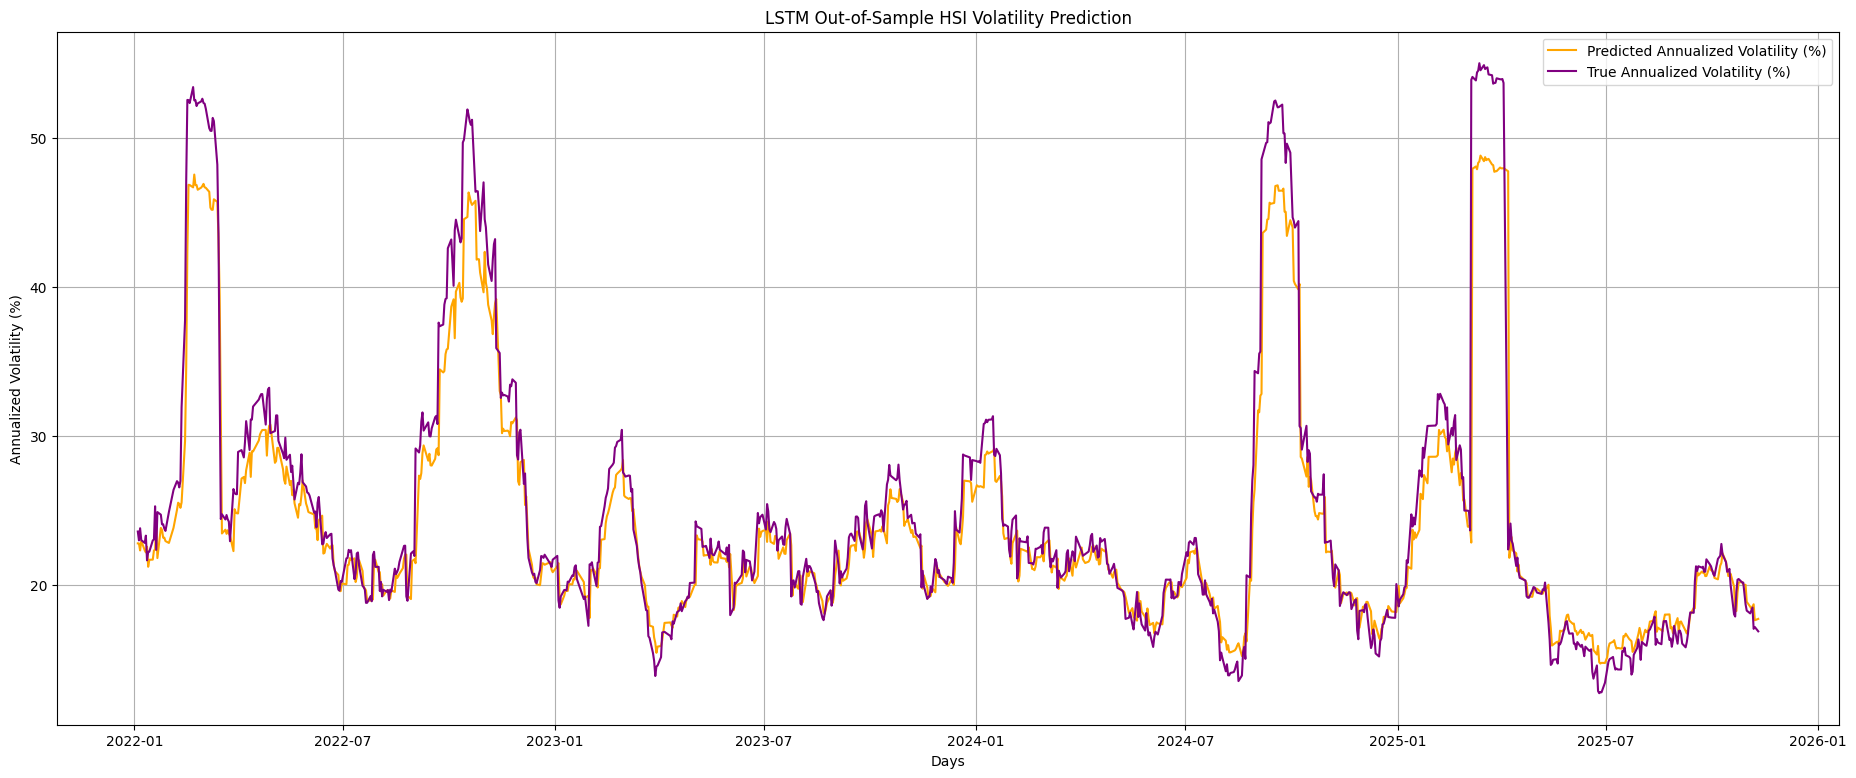

In [53]:
plt.figure(figsize=(23,9))
plt.plot(ann_pred, label='Predicted Annualized Volatility (%)', c='orange') # CUHK Colors
plt.plot(ann_true, label='True Annualized Volatility (%)', c='purple') # CUHK Colors
plt.title('LSTM Out-of-Sample HSI Volatility Prediction')
plt.xlabel('Days')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid()

### Compute Forecast Residuals

We calculate the forecast errors (residuals) in annualized percentage volatility units

In [54]:
# Forecast residuals: positive → model underestimates volatility
residuals = ann_true - ann_pred

### Visualizing LSTM Residuals

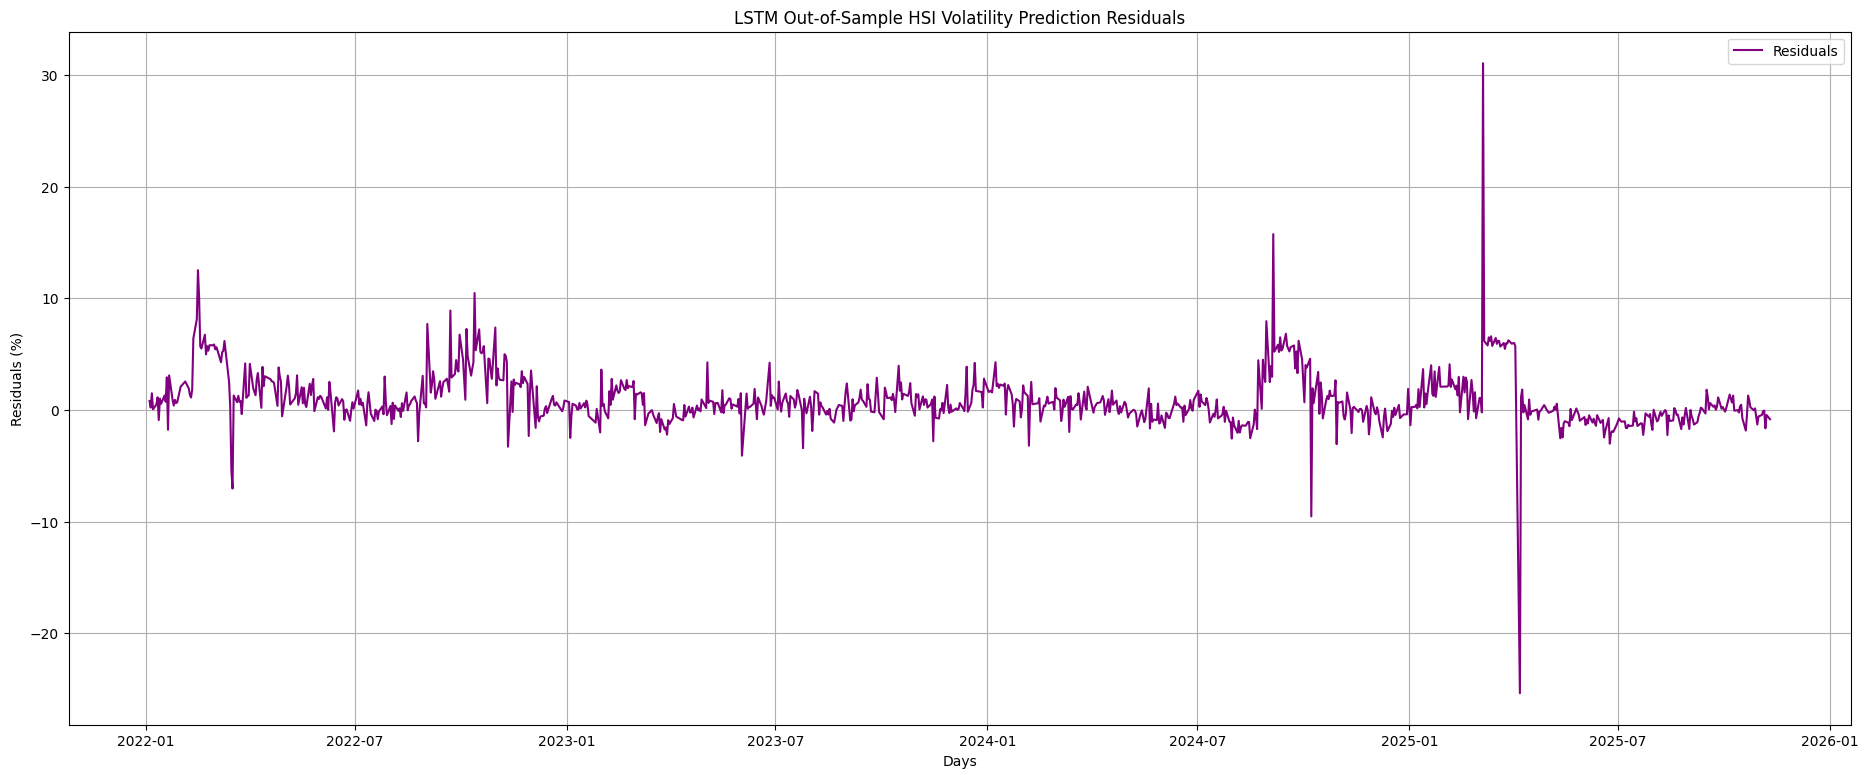

In [55]:
plt.figure(figsize=(23,9))
plt.plot(residuals, label='Residuals', color='purple')
plt.title('LSTM Out-of-Sample HSI Volatility Prediction Residuals') 
plt.xlabel('Days')
plt.ylabel('Residuals (%)')
plt.legend()
plt.grid()

### Export LSTM OOS Forecasts

In [56]:
# np.save("../results/LSTM_oos_preds.npy", preds)

### Leakage Check (Optional)

In [ ]:
# predicitons = []
# oos_df['input'] = oos_df['2800.HK'].shift(1).dropna()

# for input in oos_df['input'].dropna():
#     print(input)
#     input = torch.tensor(input, dtype=torch.float32).view(1,1,1) # (1, seq_len, 1)
#     print('INPUT:',input)
#     print('PRED:',model(input).item())
#     predicitons.append(model(input).item())